### Quadratic Equation Workflow

In [1]:
from langchain_groq import ChatGroq
from dotenv import load_dotenv
from langgraph.graph import StateGraph, START, END
from typing import TypedDict, Annotated, Literal
from pydantic import BaseModel, Field
import operator

In [2]:
load_dotenv()

True

In [3]:
model = ChatGroq(
    model="llama-3.3-70b-versatile",
    temperature=0.5
)

In [4]:
class QuadState(TypedDict):

    a: int
    b: int
    c: int

    equation: str
    discriminant: float
    result: str

In [5]:
def show_equation(state: QuadState):
    equation = f'{state['a']}x2 {state['b']}x {state['c']}'
    return {'equation': equation}

In [6]:
def calculate_discriminant(state: QuadState):
    discriminant = state['b']**2 - (4*state['a']*state['c'])
    return {'discriminant': discriminant}

In [7]:
def real_roots(state: QuadState):
    root1 = (-state['b'] + state['discriminant']**0.5)/(2*state['a'])
    root2 = (-state['b'] - state['discriminant']**0.5)/(2*state['a'])

    result = f'The Roots are {root1} {root2}'
    return {'result': result}

In [8]:
def repeated_roots(state: QuadState):
    root = (-state['b'])/(2*state['a'])

    result = f'Only repeating root is {root}'
    return {'result': result}

In [9]:
def no_real_roots(state: QuadState):
    result = f'No Real Roots'
    return {'result': result}

In [10]:
# A Routing function for conditional workflows
def check_condition(state: QuadState) -> Literal['real_roots', 'repeated_roots', 'no_real_roots']:
    d = state['discriminant']
    if d > 0:
        return 'real_roots'
    elif d == 0:
        return 'repeated_roots'
    else:
        return 'no_real_roots'

In [11]:
graph = StateGraph(QuadState)

# nodes
graph.add_node('show_equation', show_equation)
graph.add_node('calculate_discriminant', calculate_discriminant)
graph.add_node('real_roots', real_roots)
graph.add_node('repeated_roots', repeated_roots)
graph.add_node('no_real_roots', no_real_roots)

# edges
graph.add_edge(START, 'show_equation')
graph.add_edge('show_equation', 'calculate_discriminant')

graph.add_conditional_edges('calculate_discriminant', check_condition)
graph.add_edge('real_roots', END)
graph.add_edge('repeated_roots', END)
graph.add_edge('no_real_roots', END)

workflow = graph.compile()

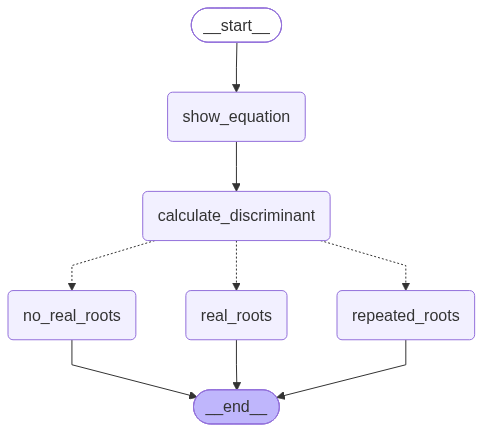

In [12]:
workflow

In [13]:
s1 = {
    'a': 4,
    'b': -5,
    'c': -4
}
workflow.invoke(s1)

{'a': 4,
 'b': -5,
 'c': -4,
 'equation': '4x2 -5x -4',
 'discriminant': 89,
 'result': 'The Roots are 1.8042476415070754 -0.5542476415070754'}

In [14]:
s2 = {
    'a': 18,
    'b': 3,
    'c': 3
}
workflow.invoke(s2)

{'a': 18,
 'b': 3,
 'c': 3,
 'equation': '18x2 3x 3',
 'discriminant': -207,
 'result': 'No Real Roots'}

### LLM Workflow

In [16]:
class SentimentSchema(BaseModel):
    sentiment: Literal['positive', 'negative'] = Field(descriptiion='Sentiment of the review')
    

C:\Users\p\AppData\Local\Temp\ipykernel_11292\1631491082.py:2: PydanticDeprecatedSince20: Using extra keyword arguments on `Field` is deprecated and will be removed. Use `json_schema_extra` instead. (Extra keys: 'descriptiion'). Deprecated in Pydantic V2.0 to be removed in V3.0. See Pydantic V2 Migration Guide at https://errors.pydantic.dev/2.13/migration/
  sentiment: Literal['positive', 'negative'] = Field(descriptiion='Sentiment of the review')


In [28]:
class DiagnosisSchema(BaseModel):
    issue_type: Literal["UX", "Performance", "Bug", "Support", "Other"] = Field(description='The category of issue mentioned in the review')
    tone: Literal["angry", "frustrated", "disappointed", "calm"] = Field(description='The emotional tone expressed by the user')
    urgency: Literal["low", "medium", "high"] = Field(description='How urgent or critical the issue appears to be')

In [30]:
structured_model = model.with_structured_output(SentimentSchema)
structured_model2 = model.with_structured_output(DiagnosisSchema)

In [20]:
class ReviewState(TypedDict):
    review: str
    sentiment: Literal['positive', 'negative']
    diagnosis: dict
    response: str

In [21]:
def find_sentiment(state: ReviewState):
    prompt = f'For the following review find out the sentiment \n {state['review']}'
    sentiment = structured_model.invoke(prompt).sentiment
    return {'sentiment': sentiment}

In [ ]:
def positive_response(state: ReviewState):
    prompt = f"""Write a warm thank-you message in response to this review:
    \n\n\"{state['review']}\"\n
Also, kindly ask the user to leave feedback on our website."""

    response = model.invoke(prompt).content
    return {'response': response}

In [31]:
def run_diagnosis(state: ReviewState):
    prompt = f"""Diagnose this negative review:\n\n{state['review']}\n"
    "Return issue_type, tone, and urgency.
"""
    response = structured_model2.invoke(prompt)
    return {'diagnosis': response.model_dump()}

In [32]:
def negative_response(state: ReviewState):
    diagnosis = state['diagnosis']
    prompt = f"""You are a support assistant.
The user had a '{diagnosis['issue_type']}' issue, sounded '{diagnosis['tone']}', and marked urgency as '{diagnosis['urgency']}'.
Write an empathetic, helpful resolution message.
"""

    response = model.invoke(prompt).content
    return {'response': response}

In [36]:
def check_sentiment(state: ReviewState) -> Literal['positive_response', 'run_diagnosis']:
    if state['sentiment'] == 'positive':
        return 'positive_response'
    else:
        return 'run_diagnosis'

In [37]:
graph = StateGraph(ReviewState)

graph.add_node('find_sentiment', find_sentiment)
graph.add_node('positive_response', positive_response)
graph.add_node('run_diagnosis', run_diagnosis)
graph.add_node('negative_response', negative_response)


graph.add_edge(START, 'find_sentiment')
graph.add_conditional_edges('find_sentiment', check_sentiment)
graph.add_edge('positive_response', END)
graph.add_edge('run_diagnosis', 'negative_response')
graph.add_edge('negative_response', END)

workflow = graph.compile()

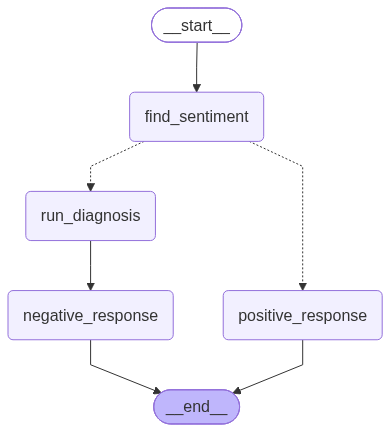

In [34]:
workflow

In [38]:
initial_state={
    'review': "I’ve been trying to log in for over an hour now, and the app keeps freezing on the authentication screen. I even tried reinstalling it, but no luck. This kind of bug is unacceptable, especially when it affects basic functionality."
}

workflow.invoke(initial_state)

{'review': 'I’ve been trying to log in for over an hour now, and the app keeps freezing on the authentication screen. I even tried reinstalling it, but no luck. This kind of bug is unacceptable, especially when it affects basic functionality.',
 'sentiment': 'negative',
 'diagnosis': {'issue_type': 'Bug', 'tone': 'angry', 'urgency': 'high'},
 'response': "I'm so sorry to hear that you're experiencing a bug issue and that it's causing frustration for you. I can imagine how annoying it must be, and I'm here to help resolve the problem as quickly as possible.\n\nI've marked your issue as high priority, and I'm committed to working with you to find a solution. Can you please provide me with more details about the bug, such as the steps you took leading up to the issue and any error messages you've received? This will help me to better understand the problem and provide a more effective solution.\n\nIn the meantime, I want to assure you that I'm doing everything I can to resolve this issue 